In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openquake.commonlib.datastore import read

In [2]:
!oq engine --lrc

job_id |     status |          start_time |         description
     1 |   complete | 2024-11-03 12:06:15.308445 | Scenario Risk Demo (Catania Tsunami) using hysea simulation no aggregation
     2 |   complete | 2024-11-03 12:06:35.087976 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 892 no aggregation
     3 |   complete | 2024-11-03 12:06:54.806854 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 1658 no aggregation
     4 |   complete | 2024-11-03 12:07:16.469549 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 3454 no aggregation
     5 |   complete | 2024-11-03 12:12:18.075475 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 7071 no aggregation
     6 |   complete | 2024-11-03 13:17:53.362380 | Scenario Risk Demo (Catania Tsunami) using hysea simulation with foglio aggregation
     7 |   complete | 2024-11-03 13:19:15.386250 | Scenario Risk Demo (C

In [9]:
dstore = read(20)
list(dstore)

['agg_keys',
 'agg_values',
 'assetcol',
 'avg_losses-rlzs',
 'crm',
 'discarded',
 'events',
 'exposure',
 'full_lt',
 'gmf_data',
 'oqparam',
 'performance_data',
 'risk_by_event',
 'rupgeoms',
 'ruptures',
 'sitecol',
 'task_info',
 'task_sent',
 'taxmap',
 'weights']

In [10]:
dstore.read_df('risk_by_event')[:100]

,event_id,agg_id,loss_id,variance,loss
0,2,3,3,0.0,9.880118e+05
1,3,3,3,0.0,1.451440e+06
2,5,3,3,0.0,4.791906e+05
3,7,3,3,0.0,3.062732e+06
4,8,3,3,0.0,8.857064e+05
...,...,...,...,...,...
95,164,3,3,0.0,1.939857e+05
96,166,3,3,0.0,1.986713e+05
97,170,3,3,0.0,1.690890e+07
98,172,3,3,0.0,1.266313e+05


In [6]:
dstore.read_df('risk_by_event')[:100]

,event_id,agg_id,loss_id,variance,loss
0,2,3,3,0.0,9.880118e+05
1,3,3,3,0.0,1.451440e+06
2,5,3,3,0.0,4.791906e+05
3,7,3,3,0.0,3.062732e+06
4,8,3,3,0.0,8.857064e+05
...,...,...,...,...,...
95,164,3,3,0.0,1.939857e+05
96,166,3,3,0.0,1.986713e+05
97,170,3,3,0.0,1.690890e+07
98,172,3,3,0.0,1.266313e+05


In [5]:
file = '/home/naveen.raguramalinga/oqdata/calc_1.hdf5'

with h5py.File(file, 'r') as f:
    agg_keys = f['agg_keys'][:]
    f.close()


# remove b in string values in the np array agg_keys,ex b'19089001000000292200' to 19089001000000292200
agg_keys = np.array([x.decode('utf-8') for x in agg_keys])

# convert the np array to a pandas dataframe
agg_keys = pd.DataFrame(agg_keys, columns=['IDAG'])
agg_keys['agg_id'] = agg_keys.index

#save IDAG and agg_id key to a csv file
agg_keys.to_csv('0_agg_keys.csv', index=False)

In [ ]:
event_info = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/info/sampling_input_CT_38.csv',header=0)
event_info['event_id']= event_info.index

run_name = ['true','892','1658','3454','7071']

for job_id in range(1, 6):
    print(f'Job {job_id} for {run_name[(job_id-1)]}')
    # Load the results
    dstore = read(job_id)

    # Extract the data
    data_event = dstore.read_df('risk_by_event')

    #Join the data with the agg_keys
    data_event = data_event.join(agg_keys.set_index('agg_id'), on='agg_id')

    #aggregate the data based on event_id
    event_loss = data_event.groupby('event_id')['loss'].sum()

    #remove events less than 500 loss value
    # event_loss = event_loss[event_loss > 500]

    #remove from data_event the events with loss less than 500
    # data_event = data_event[data_event['event_id'].isin(event_loss.index)]

    #number of events
    print('Number of events:', len(event_loss))

    #save the data to a csv file
    event_loss.to_csv(f'1_event_asset_loss_{run_name[(job_id-1)]}.csv', index=True)
    data_event.to_csv(f'2_asset_event_loss_{run_name[(job_id-1)]}.csv', index=True)

    #append event_loss to event_info
    event_info = event_info.join(event_loss, on='event_id', rsuffix=f'_{run_name[(job_id-1)]}')

#rename column loss to loss_true
event_info.rename(columns={'loss':'loss_true'}, inplace=True)

#set missing values to 0
event_info[f'loss_true'] = event_info[f'loss_true'].fillna(0)
event_info[f'loss_892'] = event_info[f'loss_892'].fillna(0)
event_info[f'loss_1658'] = event_info[f'loss_1658'].fillna(0)
event_info[f'loss_3454'] = event_info[f'loss_3454'].fillna(0)
event_info[f'loss_7071'] = event_info[f'loss_7071'].fillna(0)

#save the data to a csv file
event_info.to_csv('3_event_info_agg_loss.csv', index=False)


Job 1 for true
Number of events: 32251
Job 2 for 892
Number of events: 31017
Job 3 for 1658
Number of events: 35334
Job 4 for 3454
Number of events: 31383
Job 5 for 7071
Number of events: 30871


In [38]:
def get_loss_pml(loss,rate,threshold,PoE):

    #filter events based on threshold of 500
    rate = rate[loss>threshold]
    loss = loss[loss>threshold]

    #reset index
    rate = rate.reset_index(drop=True)
    loss = loss.reset_index(drop=True)

    #sort descending
    idx = np.argsort(loss)[::-1]
    sorted_loss = loss[idx]
    sorted_rate = rate[idx]

    #Event loss table
    ELT = pd.DataFrame({'loss':sorted_loss,'rate':sorted_rate})
    ELT['weighted_loss'] = sorted_loss*sorted_rate
    ELT['cumulative_probability'] = ELT['rate'].cumsum()

    AAL = np.sum(ELT['weighted_loss'])
    print('AAL:',AAL)

    PML = np.zeros(len(PoE))
    #find the event loss for each RP
    for i,probability_level in enumerate(PoE):
        PML[i] = ELT['loss'][ELT['cumulative_probability']>probability_level].max()

    return PML

In [40]:
#get probability of exceedance thresholds using RPs from 1 in 10 to 1 in 10e8
RP = [250,500,1000,10000,100000,1000000,10000000,100000000]
PoE = [1/rp for rp in RP]

PML_true = get_loss_pml(event_info['loss_true'],event_info['mean_prob'],5,PoE)
PML_892 = get_loss_pml(event_info['loss_892'],event_info['mean_prob'],5,PoE)
PML_1658 = get_loss_pml(event_info['loss_1658'],event_info['mean_prob'],5,PoE)
PML_3454 = get_loss_pml(event_info['loss_3454'],event_info['mean_prob'],5,PoE)
PML_7071 = get_loss_pml(event_info['loss_7071'],event_info['mean_prob'],5,PoE)

AAL: 40330.662883038436
AAL: 29159.119429175313
AAL: 37075.9934835338
AAL: 31849.38159800026
AAL: 32881.98893399761


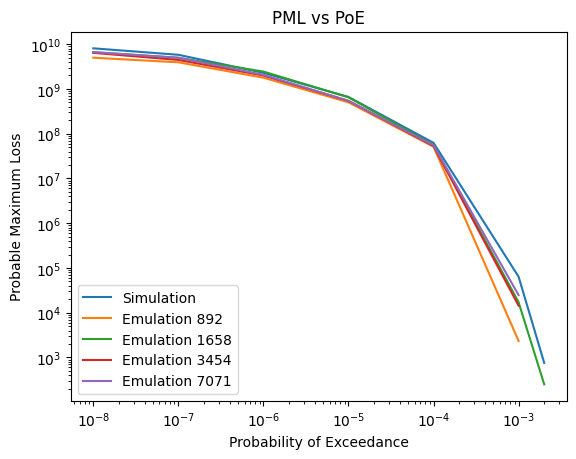

In [41]:
#plot
fig, ax = plt.subplots()
ax.plot(PoE,PML_true,label='Simulation')
ax.plot(PoE,PML_892,label='Emulation 892')
ax.plot(PoE,PML_1658,label='Emulation 1658')
ax.plot(PoE,PML_3454,label='Emulation 3454')
ax.plot(PoE,PML_7071,label='Emulation 7071')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Probability of Exceedance')
ax.set_ylabel('Probable Maximum Loss')
ax.set_title('PML vs PoE')
ax.legend()
plt.show()

In [ ]:
def print_hdf5_content(obj, name):
    """
    A recursive function to print the content of an HDF5 file.
    """
    if isinstance(obj, h5py.Group):
        print(f"Group: {name}")
        for key, item in obj.items():
            print_hdf5_content(item, f"{name}/{key}")
    elif isinstance(obj, h5py.Dataset):
        print(f"Dataset: {name}")
        print(f"Shape: {obj.shape}, Dtype: {obj.dtype}")
        print("Data:")
        print(obj[:])  # Print the actual data
    else:
        print(f"Unknown type: {name}")

with h5py.File(file, "r") as f:
    print_hdf5_content(f, '/')

In [ ]:
risk_event_sim = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/results/risk_by_event_7_simulation.csv',header=1)
risk_event_emu = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/results/risk_by_event_8_emulation.csv',header=1)

event_info = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/info/sampling_input_CT_38.csv',header=0)
event_info['event_id']= event_info.index

mean_rate = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/processed/all_eventsBS_PS53550_meanrate.txt',header=0)
mean_rate.columns = ['eve_id','mean_rate']

#link event info with risk event using event_id, keep all events in event_info
event_table = pd.merge(event_info,risk_event_sim,on='event_id',how='left')
event_table['loss_sim'] = event_table['loss']
event_table = event_table.drop(columns=['loss'])
event_table = event_table.drop(columns=['loss_type'])

event_table = pd.merge(event_table,risk_event_emu,on='event_id',how='left')
event_table['loss_emu'] = event_table['loss']
event_table = event_table.drop(columns=['loss'])
event_table = event_table.drop(columns=['loss_type'])

#set missing values to 0
event_table['loss_sim'] = event_table['loss_sim'].fillna(0)
event_table['loss_emu'] = event_table['loss_emu'].fillna(0)

#set values less than 100 to 0
event_table['loss_sim'] = np.where(event_table['loss_sim']<500,0,event_table['loss_sim'])
event_table['loss_emu'] = np.where(event_table['loss_emu']<500,0,event_table['loss_emu'])

print(np.count_nonzero(event_table['loss_sim']), 'events have loss in simulation')
print(np.count_nonzero(event_table['loss_emu']), 'events have loss in emulation')

#add mean rate to event table
event_table = pd.merge(event_table,mean_rate,on='eve_id',how='left')


30443 events have loss in simulation
30481 events have loss in emulation


In [14]:
loss = event_table['loss_sim'] #loss for event(L)
rate = event_table['mean_rate'] #mean annual rate for event(p)

#sort descending
idx = np.argsort(loss)[::-1]
sorted_loss = loss[idx]
sorted_rate = rate[idx]

#Event loss table
ELT = pd.DataFrame({'loss':sorted_loss,'rate':sorted_rate})
ELT['weighted_loss'] = sorted_loss*sorted_rate
ELT['cumulative_probability'] = ELT['rate'].cumsum()

AAL = np.sum(ELT['weighted_loss'])
print('AAL:',AAL)

#get probability of exceedance thresholds using RPs from 1 in 10 to 1 in 10e8
RP = [10,100,1000,10000,100000,1000000,10000000,100000000]
PoE = [1/rp for rp in RP]

PML_sim = np.zeros(len(PoE))
#find the event loss for each RP
for i,probability_level in enumerate(PoE):
    PML_sim[i] = ELT['loss'][ELT['cumulative_probability']>probability_level].max()



AAL: 19739.40475914385


In [15]:
loss = event_table['loss_emu'] #loss for event(L)
rate = event_table['mean_rate'] #mean annual rate for event(p)

#sort descending
idx = np.argsort(loss)[::-1]
sorted_loss = loss[idx]
sorted_rate = rate[idx]

#Event loss table
ELT = pd.DataFrame({'loss':sorted_loss,'rate':sorted_rate})
ELT['weighted_loss'] = sorted_loss*sorted_rate
ELT['cumulative_probability'] = ELT['rate'].cumsum()

AAL = np.sum(ELT['weighted_loss'])
print('AAL:',AAL)

#get probability of exceedance thresholds using RPs from 1 in 10 to 1 in 10e8
RP = [10,100,1000,10000,100000,1000000,10000000,100000000]
PoE = [1/rp for rp in RP]

PML_emu = np.zeros(len(PoE))
#find the event loss for each RP
for i,probability_level in enumerate(PoE):
    PML_emu[i] = ELT['loss'][ELT['cumulative_probability']>probability_level].max()




AAL: 17859.493909273802


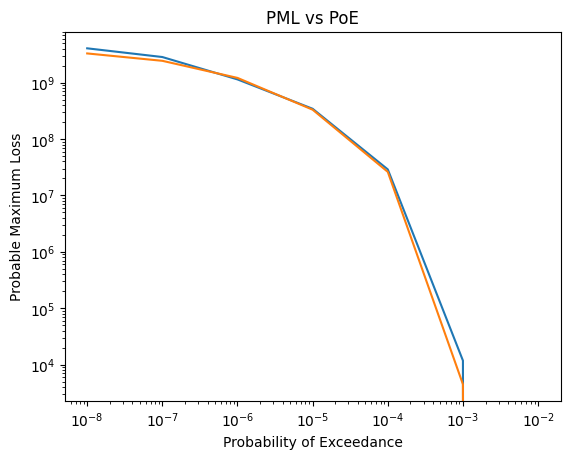

In [20]:
#plot
fig, ax = plt.subplots()
ax.plot(PoE,PML_sim,label='Simulation')
ax.plot(PoE,PML_emu,label='Emulation')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Probability of Exceedance')
ax.set_ylabel('Probable Maximum Loss')
ax.set_title('PML vs PoE')
plt.show()


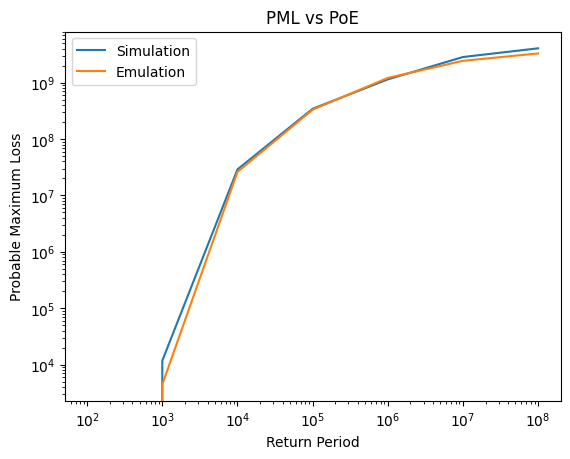

In [21]:
#plot
fig, ax = plt.subplots()
ax.plot(RP,PML_sim,label='Simulation')
ax.plot(RP,PML_emu,label='Emulation')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Return Period')
ax.set_ylabel('Probable Maximum Loss')
ax.set_title('PML vs PoE')
ax.legend()
plt.show()
